<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br><br><br>

# Listed Volatility and Variance Derivatives

**Wiley Finance (2017)**

Dr. Yves J. Hilpisch | The Python Quants GmbH

http://tpq.io | [@dyjh](http://twitter.com/dyjh) | http://books.tpq.io

<img src="https://hilpisch.com/images/lvvd_cover.png" alt="Listed Volatility and Variance Derivatives" width="30%" align="left" border="0">

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'

## Trading Volume

Source: **CFE Daily Volume and Open Interest by Product** — current file at [cdn.cboe.com/data/us/futures/market_statistics/historical_data/cfevoloi.csv](https://cdn.cboe.com/data/us/futures/market_statistics/historical_data/cfevoloi.csv) (2004 to present; values verified identical to the archived copy shipped with the book). The original book link (`cboe.com/products/futures/market-data/historical-data-archive`) is dead. Related free Cboe sources: per-contract VIX futures price/volume files (`.../historical_data/VX/VX_<expiry>.csv`), VIX/VVIX index history (`cdn.cboe.com/api/global/us_indices/daily_prices/`), and the daily VIX option-chain snapshot accumulated by `scripts/collect_cboe_data.py` (see `cboe_instruments.yaml`).

In [2]:
## CFE daily volume & open interest by product, straight from the Cboe CDN
URL = ('https://cdn.cboe.com/data/us/futures/market_statistics/'
       'historical_data/cfevoloi.csv')
data = pd.read_csv(URL, skiprows=1,
                   index_col=0, parse_dates=True, encoding='latin1')
## offline fallback: the archived copy shipped with the book
## data = pd.read_csv('data/cfevoloi.csv', skiprows=1,
##                    index_col=0, parse_dates=True, encoding='latin1')


In [3]:
data.iloc[:, :10].info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5650 entries, 2004-03-26 to 2026-09-08
Data columns (total 10 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   VOLATILITY INDEX VOLUME                                  5650 non-null   int64  
 1   VOLATILITY INDEX OI                                      5650 non-null   int64  
 2   S&P 500 Variance Volume                                  2847 non-null   float64
 3   S&P 500 Variance OI                                      2847 non-null   float64
 4   Corporate Bond High Yield Volume                         1968 non-null   float64
 5   Corporate Bond High Yield OI                             1968 non-null   float64
 6   Corporate Bond Liquid Investment Grade Volume            1968 non-null   float64
 7   Corporate Bond Liquid Investment Grade OI                1968 non-null   float64
 8   CBOE/CBOT 10YR US TRE

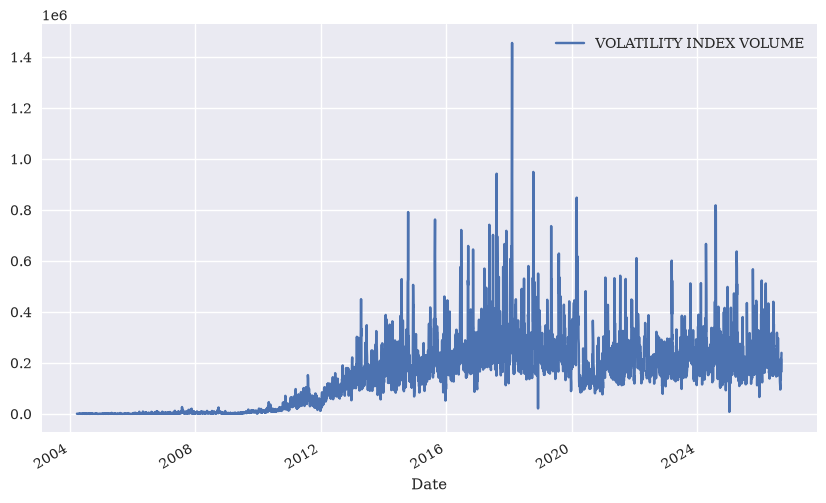

In [4]:
data['VOLATILITY INDEX VOLUME'].plot(figsize=(10, 6),
                                     legend=True);

In [5]:
to_plot = pd.DataFrame({'VIX volume': data['VOLATILITY INDEX VOLUME']})

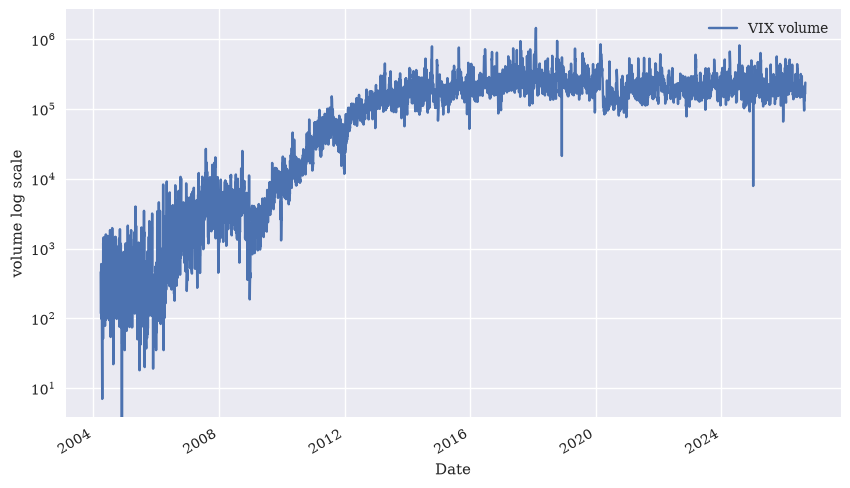

In [6]:
to_plot.plot(figsize=(10, 6), legend=True, logy=True);
plt.ylabel('volume log scale');

Text(0, 0.5, 'volume log scale')

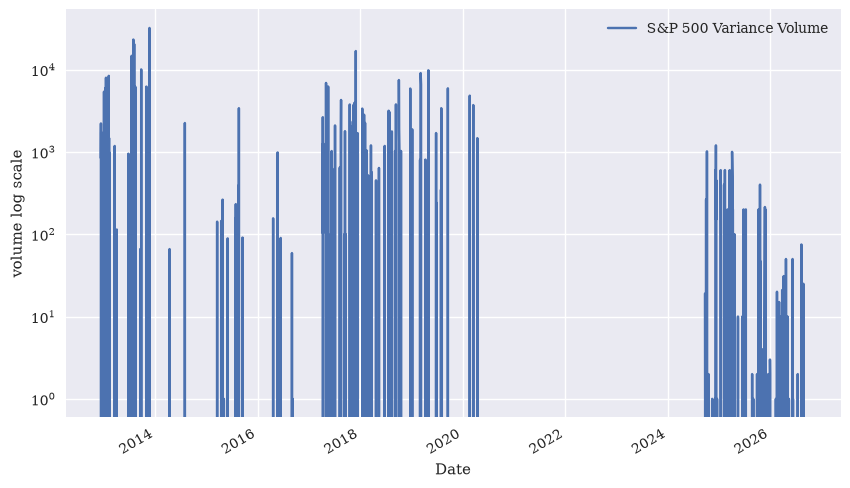

In [7]:
data['S&P 500 Variance Volume'].plot(figsize=(10, 6),
                            legend=True, logy=True);
plt.ylabel('volume log scale')

## Price Data

In [8]:
# url = 'https://hilpisch.com/vola_eikon_eod_data.csv'
url = 'data/vola_eikon_eod_data.csv'

In [9]:
data = pd.read_csv(url, index_col=0, parse_dates=True)

In [10]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2670 entries, 2010-01-04 to 2020-10-23
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   .SPX    2670 non-null   float64
 1   .VIX    2670 non-null   float64
 2   .VVIX   2670 non-null   float64
 3   .V2TX   2670 non-null   float64
dtypes: float64(4)
memory usage: 104.3 KB


In [11]:
data.head()

,.SPX,.VIX,.VVIX,.V2TX
Date,,,,
2010-01-04,1132.99,20.04,73.30,23.5136
2010-01-05,1136.52,19.35,70.36,23.1342
2010-01-06,1137.14,19.16,67.65,22.9753
2010-01-07,1141.69,19.06,67.15,22.6947
2010-01-08,1144.98,18.13,65.71,21.9757


### VIX vs VSTOXX

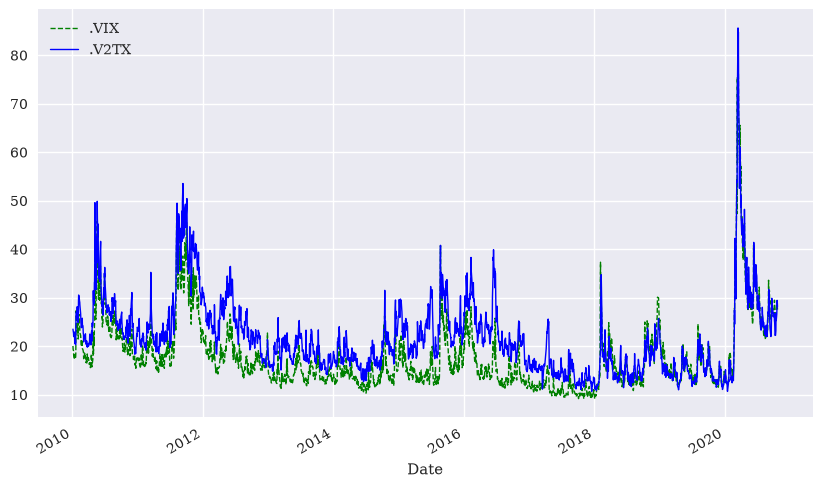

In [12]:
data[['.VIX', '.V2TX']].plot(figsize=(10, 6),
                             style=['g--', 'b'], lw=1.0);

In [13]:
ret = np.log(data[['.VIX', '.V2TX']] / data[['.VIX', '.V2TX']].shift(1))

In [14]:
ret.corr()

,.VIX,.V2TX
.VIX,1.000000,0.561704
.V2TX,0.561704,1.000000


### VIX vs VVIX

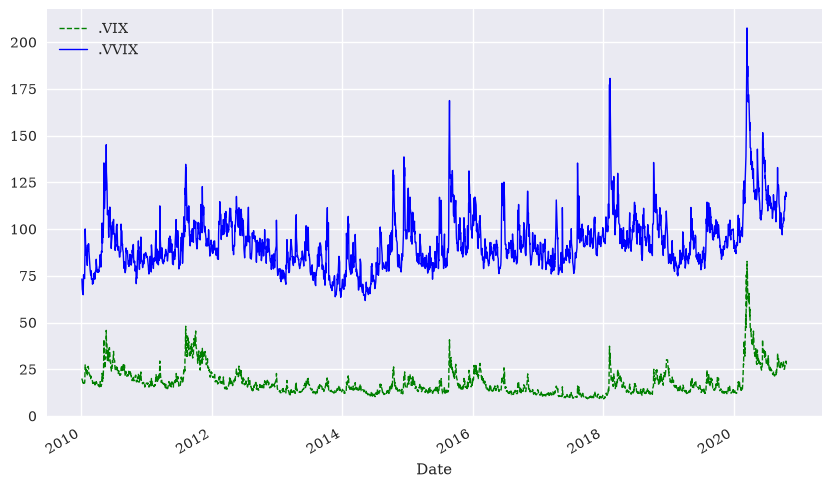

In [15]:
data[['.VIX', '.VVIX']].plot(figsize=(10, 6),
                             style=['g--', 'b'], lw=1.0);

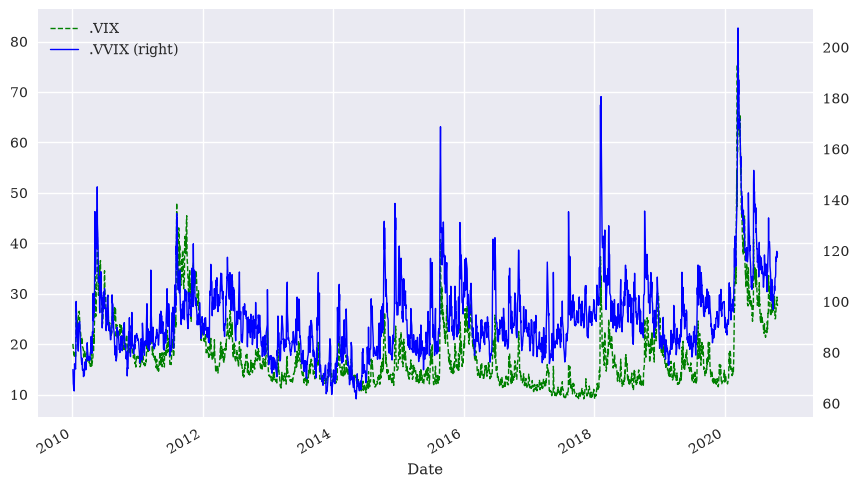

In [16]:
data[['.VIX', '.VVIX']].plot(figsize=(10, 6),
            style=['g--', 'b'], lw=1.0, secondary_y='.VVIX');

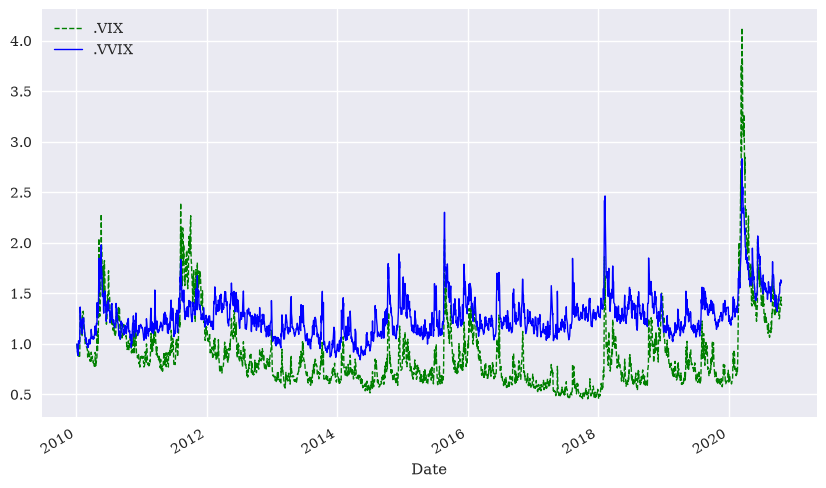

In [17]:
(data[['.VIX', '.VVIX']] / data[['.VIX', '.VVIX']].iloc[0]).plot(
    figsize=(10, 6), style=['g--', 'b'], lw=1.0);

In [18]:
ret = np.log(data[['.VIX', '.VVIX']] / data[['.VIX', '.VVIX']].shift(1))

In [19]:
ret.corr()

,.VIX,.VVIX
.VIX,1.000000,0.829932
.VVIX,0.829932,1.000000


## S&P 500 vs VIX

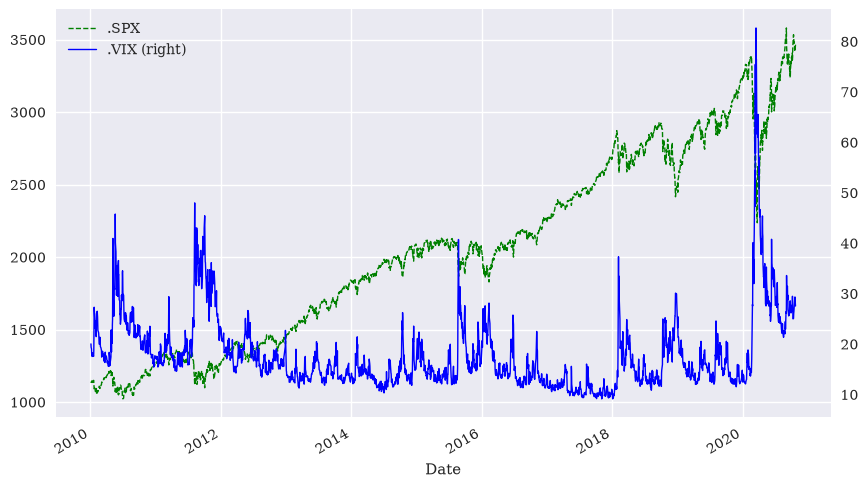

In [20]:
data[['.SPX', '.VIX']].plot(figsize=(10, 6),
            style=['g--', 'b'], lw=1.0, secondary_y='.VIX');

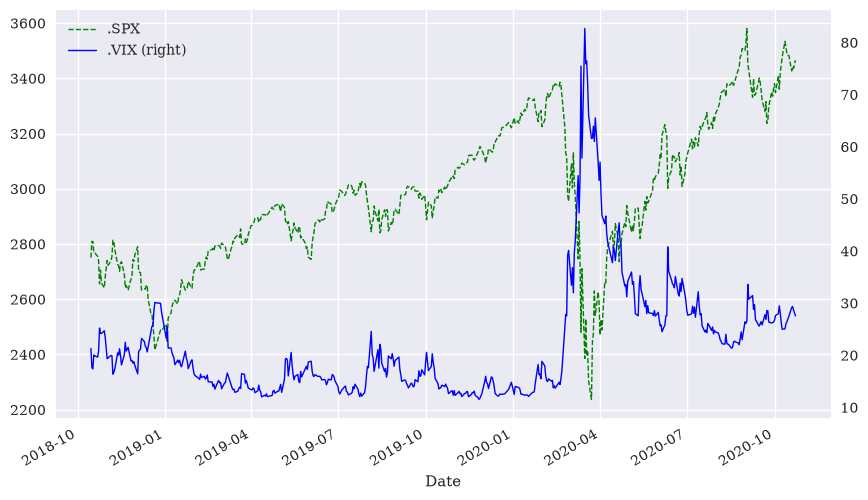

In [21]:
data[['.SPX', '.VIX']].iloc[-500:].plot(figsize=(10, 6),
            style=['g--', 'b'], lw=1.0, secondary_y='.VIX');

In [22]:
ret = np.log(data[['.SPX', '.VIX']] / data[['.SPX', '.VIX']].shift(1))

In [23]:
ret.corr()

,.SPX,.VIX
.SPX,1.000000,-0.756791
.VIX,-0.756791,1.000000


## Eikon Data Retrieval

**Note (2026-09-05):** This section is legacy and not runnable as-is. It uses the `eikon` Python package, which talks to a locally running Refinitiv Eikon desktop terminal. Eikon was discontinued by LSEG on June 30, 2025 and replaced by LSEG Workspace, and even while it existed, API access required a paid Eikon Premium subscription (no free tier) plus the desktop app running locally. The cells below are kept for reference — their outputs are from a prior run against a live Eikon session and cannot be reproduced without an active institutional LSEG Workspace subscription (see the [LSEG Data Library for Python](https://developers.lseg.com/en/api-catalog/lseg-data-platform/lseg-data-library-for-python) for the current equivalent). Note also that `data.append(raw)` in the retrieval loop below relies on `DataFrame.append`, removed in pandas 2.0+; it would need to be rewritten with `pd.concat` to run on current pandas even with API access restored.

In [24]:
import pandas as pd

In [25]:
## import eikon as ek
## import configparser as cp
## c = cp.ConfigParser()
## c.read('../eikon.cfg')
## ek.set_app_key(c['eikon']['app_key'])

In [26]:
rics = ['.V2TX', '.V6I1', '.V6I2', '.V6I3', '.V6I4', '.V6I5', '.V6I6', '.V6I7', '.V6I8']

In [27]:
## data = pd.DataFrame()
## for year in [2010, 2012, 2014, 2016, 2018, 2020]:
##     print(year)
##     raw = ek.get_timeseries(rics, start_date=f'{year}-1-1',
##                     end_date=f'{year + 2}-1-1', fields='CLOSE')
##     data = data.append(raw)
## data.dropna(inplace=True)

In [28]:
data.tail()

,.SPX,.VIX,.VVIX,.V2TX
Date,,,,
2020-10-19,3426.92,29.18,119.76,26.6186
2020-10-20,3443.12,29.35,119.59,27.6293
2020-10-21,3435.56,28.65,117.47,29.4488
2020-10-22,3453.49,28.11,118.60,28.9879
2020-10-23,3465.39,27.55,118.94,28.1570


<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

<a href="http://tpq.io" target="_blank">http://tpq.io</a> | <a href="http://twitter.com/dyjh" target="_blank">@dyjh</a> | <a href="mailto:team@tpq.io">team@tpq.io</a>